<a href="https://colab.research.google.com/github/kartoffeloshka/Intern_project/blob/main/DL3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [2]:
!pip install torch torchvision torchaudio
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install matplotlib seaborn
!pip install umap-learn
!pip install wandb
!pip install tqdm

In [3]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

In [4]:
class Config:

    seed = 42

    batch_size = 128

    latent_dim = 64

    epochs = 40

    lr = 1e-3

    device = "cuda" if torch.cuda.is_available() else "cpu"

config = Config()

In [5]:
def set_seed(seed):

    torch.manual_seed(seed)
    np.random.seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(config.seed)

In [6]:
!wget https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
!unzip human+activity+recognition+using+smartphones.zip

--2026-03-06 12:15:44--  https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘human+activity+recognition+using+smartphones.zip’

human+activity+reco     [     <=>            ]  58.18M  70.2MB/s    in 0.8s    

2026-03-06 12:15:45 (70.2 MB/s) - ‘human+activity+recognition+using+smartphones.zip’ saved [61005872]

Archive:  human+activity+recognition+using+smartphones.zip
 extracting: UCI HAR Dataset.names   
 extracting: UCI HAR Dataset.zip     


In [7]:
def load_ucihar():

    base = "UCI HAR Dataset"

    X_train = pd.read_csv(
        "X_train.txt",
        delim_whitespace=True,
        header=None
    )

    y_train = pd.read_csv(
        "y_train.txt",
        header=None
    )

    X_test = pd.read_csv(
        "X_test.txt",
        delim_whitespace=True,
        header=None
    )

    y_test = pd.read_csv(
        "y_test.txt",
        header=None
    )

    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_ucihar()

print(X_train.shape)

/tmp/ipykernel_434/2847476697.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(
/tmp/ipykernel_434/2847476697.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv(


(7352, 561)


In [8]:
def create_views(X):

    X = X.values

    v1 = X[:,0:140]
    v2 = X[:,140:280]
    v3 = X[:,280:420]
    v4 = X[:,420:561]

    return v1, v2, v3, v4

In [9]:
scalers = [StandardScaler() for _ in range(4)]

def normalize_views(v1,v2,v3,v4):

    views = [v1,v2,v3,v4]

    norm = []

    for i,v in enumerate(views):

        v = scalers[i].fit_transform(v)

        norm.append(v)

    return norm

In [10]:
class MultiViewDataset(Dataset):

    def __init__(self, X, y):

        v1,v2,v3,v4 = create_views(X)

        v1,v2,v3,v4 = normalize_views(v1,v2,v3,v4)

        self.v1 = torch.tensor(v1).float()
        self.v2 = torch.tensor(v2).float()
        self.v3 = torch.tensor(v3).float()
        self.v4 = torch.tensor(v4).float()

        self.y = torch.tensor(y.values).long().squeeze()

    def __len__(self):

        return len(self.y)

    def __getitem__(self,idx):

        return (
            self.v1[idx],
            self.v2[idx],
            self.v3[idx],
            self.v4[idx],
            self.y[idx]
        )

In [11]:
train_dataset = MultiViewDataset(X_train,y_train)
test_dataset = MultiViewDataset(X_test,y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size
)

In [12]:
batch = next(iter(train_loader))

v1,v2,v3,v4,y = batch

print(v1.shape)
print(v2.shape)
print(v3.shape)
print(v4.shape)

torch.Size([128, 140])
torch.Size([128, 140])
torch.Size([128, 140])
torch.Size([128, 141])


In [13]:
class EncoderMLP(nn.Module):

    def __init__(self, input_dim, latent_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128,latent_dim)

        )

    def forward(self,x):

        z = self.net(x)

        return z

In [14]:
class TransformerEncoder(nn.Module):

    def __init__(self,input_dim,latent_dim):

        super().__init__()

        self.embed = nn.Linear(input_dim,64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.fc = nn.Linear(64,latent_dim)

    def forward(self,x):

        x = x.unsqueeze(1)

        x = self.embed(x)

        h = self.transformer(x)

        h = h.mean(dim=1)

        z = self.fc(h)

        return z

In [15]:
class DecoderMLP(nn.Module):

    def __init__(self,latent_dim,output_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(latent_dim,128),
            nn.ReLU(),

            nn.Linear(128,256),
            nn.ReLU(),

            nn.Linear(256,output_dim)

        )

    def forward(self,z):

        x_hat = self.net(z)

        return x_hat

In [16]:
class MetaFusion(nn.Module):

    def __init__(self,latent_dim):

        super().__init__()

        self.gate = nn.Sequential(

            nn.Linear(latent_dim*4,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,4)

        )

    def forward(self,z_list):

        concat = torch.cat(z_list,dim=1)

        weights = torch.softmax(self.gate(concat),dim=1)

        z_f = 0

        for i in range(4):

            z_f += weights[:,i].unsqueeze(1) * z_list[i]

        return z_f,weights

In [17]:
class ConcatFusion(nn.Module):

    def __init__(self,latent_dim):

        super().__init__()

        self.project = nn.Linear(latent_dim*4,latent_dim)

    def forward(self,z_list):

        z = torch.cat(z_list,dim=1)

        z = self.project(z)

        return z,None

In [18]:
class AttentionFusion(nn.Module):

    def __init__(self,latent_dim):

        super().__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim=latent_dim,
            num_heads=4,
            batch_first=True
        )

    def forward(self,z_list):

        z = torch.stack(z_list,dim=1)

        fused,_ = self.attn(z,z,z)

        z_f = fused.mean(dim=1)

        return z_f,None

In [19]:
class TransformerFusion(nn.Module):

    def __init__(self,latent_dim):

        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim,
            nhead=4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

    def forward(self,z_list):

        z = torch.stack(z_list,dim=1)

        fused = self.transformer(z)

        z_f = fused.mean(dim=1)

        return z_f,None

In [20]:
class MultiViewAutoencoder(nn.Module):

    def __init__(self,fusion_type="meta"):

        super().__init__()

        ld = config.latent_dim

        self.e1 = EncoderMLP(140,ld)
        self.e2 = EncoderMLP(140,ld)
        self.e3 = EncoderMLP(140,ld)
        self.e4 = TransformerEncoder(141,ld)

        if fusion_type=="meta":
            self.fusion = MetaFusion(ld)

        elif fusion_type=="concat":
            self.fusion = ConcatFusion(ld)

        elif fusion_type=="attention":
            self.fusion = AttentionFusion(ld)

        elif fusion_type=="transformer":
            self.fusion = TransformerFusion(ld)

        self.d1 = DecoderMLP(ld,140)
        self.d2 = DecoderMLP(ld,140)
        self.d3 = DecoderMLP(ld,140)
        self.d4 = DecoderMLP(ld,141)

    def forward(self,v1,v2,v3,v4):

        z1 = self.e1(v1)
        z2 = self.e2(v2)
        z3 = self.e3(v3)
        z4 = self.e4(v4)

        zf,weights = self.fusion([z1,z2,z3,z4])

        r1 = self.d1(zf)
        r2 = self.d2(zf)
        r3 = self.d3(zf)
        r4 = self.d4(zf)

        return r1,r2,r3,r4,zf,weights

In [21]:
model = MultiViewAutoencoder(
    fusion_type="meta"
)

model = model.to(config.device)

print(model)

MultiViewAutoencoder(
  (e1): EncoderMLP(
    (net): Sequential(
      (0): Linear(in_features=140, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (e2): EncoderMLP(
    (net): Sequential(
      (0): Linear(in_features=140, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (e3): EncoderMLP(
    (net): Sequential(
      (

In [22]:
v1,v2,v3,v4,y = next(iter(train_loader))

v1 = v1.to(config.device)
v2 = v2.to(config.device)
v3 = v3.to(config.device)
v4 = v4.to(config.device)

outputs = model(v1,v2,v3,v4)

for o in outputs:
    if o is not None:
        print(o.shape)

torch.Size([128, 140])
torch.Size([128, 140])
torch.Size([128, 140])
torch.Size([128, 141])
torch.Size([128, 64])
torch.Size([128, 4])


In [23]:
def reconstruction_loss(v1,v2,v3,v4,r1,r2,r3,r4):

    l1 = F.mse_loss(r1,v1)
    l2 = F.mse_loss(r2,v2)
    l3 = F.mse_loss(r3,v3)
    l4 = F.mse_loss(r4,v4)

    loss = l1 + l2 + l3 + l4

    return loss

In [24]:
def cross_view_loss(z_list):

    loss = 0
    count = 0

    for i in range(len(z_list)):
        for j in range(i+1,len(z_list)):

            loss += F.mse_loss(z_list[i],z_list[j])
            count += 1

    return loss / count

In [25]:
class ContrastiveLoss(nn.Module):

    def __init__(self,temperature=0.5):

        super().__init__()

        self.temperature = temperature

    def forward(self,z):

        z = F.normalize(z,dim=1)

        sim = torch.matmul(z,z.T)

        sim = sim / self.temperature

        labels = torch.arange(z.size(0)).to(z.device)

        loss = F.cross_entropy(sim,labels)

        return loss

In [26]:
contrastive = ContrastiveLoss()

def total_loss(v1,v2,v3,v4,
               r1,r2,r3,r4,
               zf,
               z_list):

    rec = reconstruction_loss(v1,v2,v3,v4,r1,r2,r3,r4)

    cv = cross_view_loss(z_list)

    con = contrastive(zf)

    loss = rec + 0.2*cv + 0.1*con

    return loss,rec,cv,con

In [27]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config.lr
)

In [28]:
def train_step(batch):

    v1,v2,v3,v4,y = batch

    v1 = v1.to(config.device)
    v2 = v2.to(config.device)
    v3 = v3.to(config.device)
    v4 = v4.to(config.device)

    optimizer.zero_grad()

    r1,r2,r3,r4,zf,weights = model(v1,v2,v3,v4)

    z1 = model.e1(v1)
    z2 = model.e2(v2)
    z3 = model.e3(v3)
    z4 = model.e4(v4)

    z_list = [z1,z2,z3,z4]

    loss,rec,cv,con = total_loss(
        v1,v2,v3,v4,
        r1,r2,r3,r4,
        zf,
        z_list
    )

    loss.backward()

    optimizer.step()

    return loss.item(),rec.item(),cv.item(),con.item()

In [29]:
def eval_step(batch):

    v1,v2,v3,v4,y = batch

    v1 = v1.to(config.device)
    v2 = v2.to(config.device)
    v3 = v3.to(config.device)
    v4 = v4.to(config.device)

    with torch.no_grad():

        r1,r2,r3,r4,zf,weights = model(v1,v2,v3,v4)

        z1 = model.e1(v1)
        z2 = model.e2(v2)
        z3 = model.e3(v3)
        z4 = model.e4(v4)

        z_list = [z1,z2,z3,z4]

        loss,rec,cv,con = total_loss(
            v1,v2,v3,v4,
            r1,r2,r3,r4,
            zf,
            z_list
        )

    return loss.item()

In [31]:
import wandb

wandb.init(
    project="DL3-meta-fusion-multiview",
    config={
        "epochs":config.epochs,
        "batch_size":config.batch_size,
        "latent_dim":config.latent_dim
    }
)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: krishna-singh-2192003 (krishna-singh-2192003-nit-hamirpur-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [34]:
for epoch in range(config.epochs):

    model.train()

    train_loss = 0

    rec_loss = 0
    cv_loss = 0
    con_loss = 0

    for batch in tqdm(train_loader):

        loss,rec,cv,con = train_step(batch)

        train_loss += loss
        rec_loss += rec
        cv_loss += cv
        con_loss += con


    train_loss /= len(train_loader)
    rec_loss /= len(train_loader)
    cv_loss /= len(train_loader)
    con_loss /= len(train_loader)


    model.eval()

    val_loss = 0

    for batch in test_loader:

        val_loss += eval_step(batch)

    val_loss /= len(test_loader)


    wandb.log({

        "train_loss":train_loss,
        "val_loss":val_loss,
        "reconstruction_loss":rec_loss,
        "cross_view_loss":cv_loss,
        "contrastive_loss":con_loss

    })


    print(f"Epoch {epoch+1}")

    print("Train Loss:",train_loss)
    print("Val Loss:",val_loss)

100%|██████████| 58/58 [00:01<00:00, 29.84it/s]


Epoch 1
Train Loss: 2.5517340980727097
Val Loss: 2.0097516924142838


100%|██████████| 58/58 [00:01<00:00, 42.80it/s]


Epoch 2
Train Loss: 1.7945742422136768
Val Loss: 1.8378401746352513


100%|██████████| 58/58 [00:01<00:00, 43.15it/s]


...

Epoch 38
Train Loss: 0.6816949371633858
Val Loss: 0.8652848104635874


100%|██████████| 58/58 [00:01<00:00, 44.42it/s]


Epoch 39
Train Loss: 0.6794194568847788
Val Loss: 0.8384527191519737


100%|██████████| 58/58 [00:01<00:00, 43.52it/s]


Epoch 40
Train Loss: 0.6755067212828274
Val Loss: 0.8494618386030197


In [35]:
def corrupt_view(view, noise_level=0.5):

    noise = torch.randn_like(view) * noise_level

    corrupted = view + noise

    return corrupted

In [36]:
model.eval()

batch = next(iter(test_loader))

v1,v2,v3,v4,y = batch

v1 = v1.to(config.device)
v2 = v2.to(config.device)
v3 = v3.to(config.device)
v4 = v4.to(config.device)

# corrupt view 2 (gyroscope)

v2_corrupted = corrupt_view(v2)

with torch.no_grad():

    r1,r2,r3,r4,zf,weights = model(v1,v2_corrupted,v3,v4)

print("Meta-Fusion Weights Example:")
print(weights[:5])

Meta-Fusion Weights Example:
tensor([[0.3586, 0.3093, 0.0944, 0.2377],
        [0.2721, 0.3163, 0.1282, 0.2834],
        [0.2782, 0.3177, 0.1344, 0.2697],
        [0.2649, 0.3164, 0.1275, 0.2912],
        [0.2643, 0.2883, 0.1568, 0.2905]], device='cuda:0')


In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(true,pred):

    true = true.cpu().numpy()
    pred = pred.cpu().numpy()

    mse = mean_squared_error(true,pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true,pred)

    return mse,rmse,mae

In [38]:
def evaluate_reconstruction():

    model.eval()

    mse_total = []
    rmse_total = []
    mae_total = []

    with torch.no_grad():

        for batch in test_loader:

            v1,v2,v3,v4,y = batch

            v1 = v1.to(config.device)
            v2 = v2.to(config.device)
            v3 = v3.to(config.device)
            v4 = v4.to(config.device)

            r1,r2,r3,r4,zf,_ = model(v1,v2,v3,v4)

            mse,rmse,mae = compute_metrics(v1,r1)

            mse_total.append(mse)
            rmse_total.append(rmse)
            mae_total.append(mae)

    mse_mean = np.mean(mse_total)
    rmse_mean = np.mean(rmse_total)
    mae_mean = np.mean(mae_total)

    print("MSE:",mse_mean)
    print("RMSE:",rmse_mean)
    print("MAE:",mae_mean)

    return mse_mean

In [39]:
def extract_latent():

    model.eval()

    Z = []
    Y = []

    with torch.no_grad():

        for batch in test_loader:

            v1,v2,v3,v4,y = batch

            v1 = v1.to(config.device)
            v2 = v2.to(config.device)
            v3 = v3.to(config.device)
            v4 = v4.to(config.device)

            _,_,_,_,zf,_ = model(v1,v2,v3,v4)

            Z.append(zf.cpu())
            Y.append(y)

    Z = torch.cat(Z)
    Y = torch.cat(Y)

    return Z,Y

In [40]:
def fisher_ratio(Z,Y):

    Z = Z.numpy()
    Y = Y.numpy()

    classes = np.unique(Y)

    overall_mean = np.mean(Z,axis=0)

    between = 0
    within = 0

    for c in classes:

        Zc = Z[Y==c]

        mean_c = np.mean(Zc,axis=0)

        between += len(Zc) * np.sum((mean_c - overall_mean)**2)

        within += np.sum((Zc - mean_c)**2)

    return between / within


Z,Y = extract_latent()

print("Fisher Discriminant Ratio:",fisher_ratio(Z,Y))

Fisher Discriminant Ratio: 0.29787585


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

In [42]:
Z_train,Y_train = extract_latent()

clf = LogisticRegression(max_iter=1000)

clf.fit(Z_train,Y_train)

pred = clf.predict(Z_train)

acc = accuracy_score(Y_train,pred)

print("Classification Accuracy:",acc)

Classification Accuracy: 0.9728537495758398


In [43]:
prob = clf.predict_proba(Z_train)

auc = roc_auc_score(Y_train,prob,multi_class='ovr')

print("AUC:",auc)

AUC: 0.9987165823990282


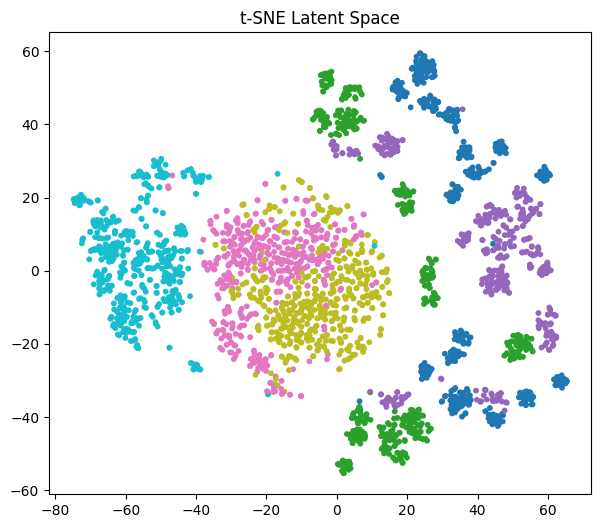

In [44]:
Z,Y = extract_latent()

tsne = TSNE(n_components=2,perplexity=30)

emb = tsne.fit_transform(Z)

plt.figure(figsize=(7,6))

plt.scatter(
    emb[:,0],
    emb[:,1],
    c=Y,
    cmap='tab10',
    s=10
)

plt.title("t-SNE Latent Space")
plt.show()

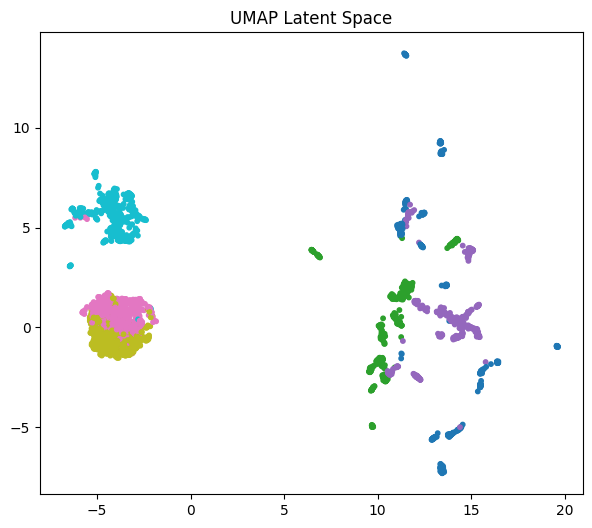

In [45]:
reducer = umap.UMAP()

emb = reducer.fit_transform(Z)

plt.figure(figsize=(7,6))

plt.scatter(
    emb[:,0],
    emb[:,1],
    c=Y,
    cmap='tab10',
    s=10
)

plt.title("UMAP Latent Space")
plt.show()

In [46]:
fusion_methods = ["concat","attention","transformer","meta"]

results = {}

for f in fusion_methods:

    print("Training:",f)

    model = MultiViewAutoencoder(fusion_type=f).to(config.device)

    optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

    for epoch in range(5):

        for batch in train_loader:

            loss,_,_,_ = train_step(batch)

    mse = evaluate_reconstruction()

    results[f] = mse

Training: concat
MSE: 0.316216887285312
RMSE: 0.558087317698404
MAE: 0.35320499415198964
Training: attention
MSE: 0.37560784878830117
RMSE: 0.6086062239409888
MAE: 0.38390352328618366
Training: transformer
MSE: 0.3991646890838941
RMSE: 0.6275397683110459
MAE: 0.397143026192983
Training: meta
MSE: 0.294275655100743
RMSE: 0.5380580269242624
MAE: 0.34771789858738583


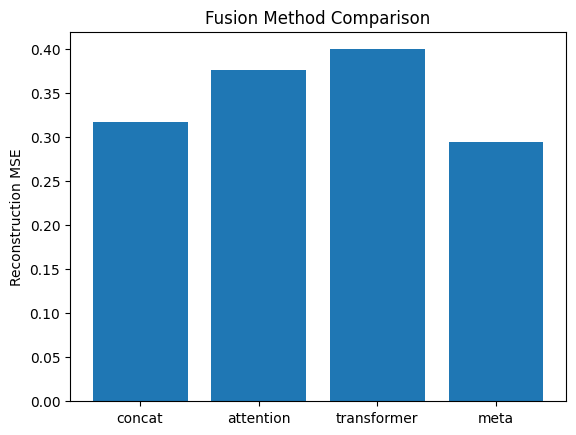

In [47]:
methods = list(results.keys())

scores = list(results.values())

plt.bar(methods,scores)

plt.title("Fusion Method Comparison")

plt.ylabel("Reconstruction MSE")

plt.show()

In [48]:
results_df = pd.DataFrame({
    "Fusion Method": list(results.keys()),
    "Reconstruction MSE": list(results.values())
})

results_df

,Fusion Method,Reconstruction MSE
0,concat,0.316217
1,attention,0.375608
2,transformer,0.399165
3,meta,0.294276


In [49]:
results_df.to_csv("fusion_results.csv",index=False)

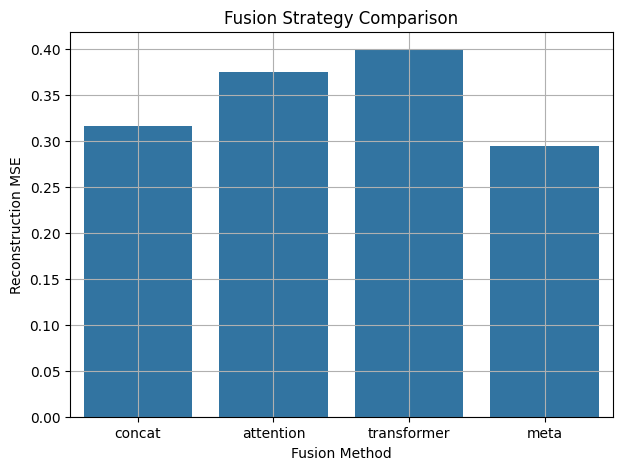

In [50]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Fusion Method",
    y="Reconstruction MSE",
    data=results_df
)

plt.title("Fusion Strategy Comparison")
plt.xlabel("Fusion Method")
plt.ylabel("Reconstruction MSE")

plt.grid(True)

plt.savefig("fusion_comparison_plot.png",dpi=300)

plt.show()

In [51]:
def collect_weights():

    model.eval()

    weights_all = []

    with torch.no_grad():

        for batch in test_loader:

            v1,v2,v3,v4,y = batch

            v1 = v1.to(config.device)
            v2 = v2.to(config.device)
            v3 = v3.to(config.device)
            v4 = v4.to(config.device)

            _,_,_,_,_,weights = model(v1,v2,v3,v4)

            weights_all.append(weights.cpu())

    weights_all = torch.cat(weights_all)

    return weights_all

In [52]:
weights_all = collect_weights()

mean_weights = weights_all.mean(dim=0)

print("Average View Weights:")
print(mean_weights)

Average View Weights:
tensor([0.5789, 0.2714, 0.1022, 0.0475])


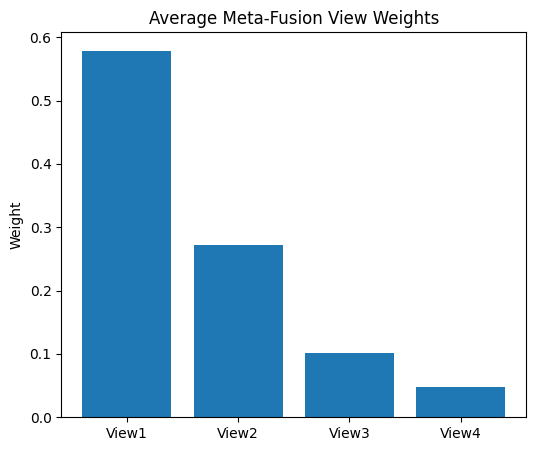

In [53]:
views = ["View1","View2","View3","View4"]

plt.figure(figsize=(6,5))

plt.bar(views,mean_weights.numpy())

plt.title("Average Meta-Fusion View Weights")
plt.ylabel("Weight")

plt.savefig("view_importance.png",dpi=300)

plt.show()

In [54]:
model.eval()

batch = next(iter(test_loader))

v1,v2,v3,v4,y = batch

v1 = v1.to(config.device)
v2 = v2.to(config.device)
v3 = v3.to(config.device)
v4 = v4.to(config.device)

with torch.no_grad():

    _,_,_,_,_,weights_clean = model(v1,v2,v3,v4)

v2_corrupted = corrupt_view(v2)

with torch.no_grad():

    _,_,_,_,_,weights_corrupt = model(v1,v2_corrupted,v3,v4)

clean_mean = weights_clean.mean(dim=0).cpu()
corrupt_mean = weights_corrupt.mean(dim=0).cpu()

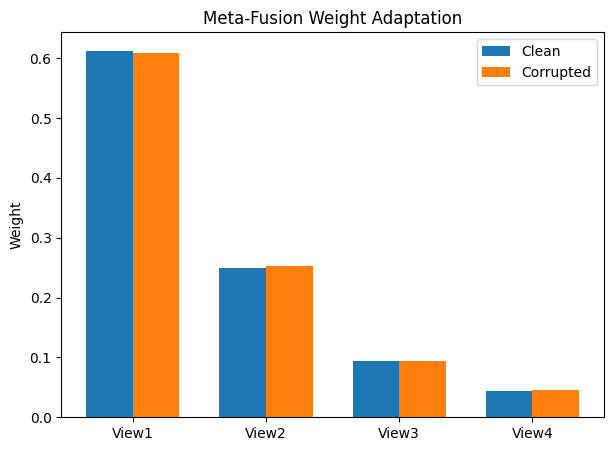

In [55]:
x = np.arange(4)

width = 0.35

plt.figure(figsize=(7,5))

plt.bar(x-width/2,clean_mean,width,label="Clean")
plt.bar(x+width/2,corrupt_mean,width,label="Corrupted")

plt.xticks(x,["View1","View2","View3","View4"])

plt.title("Meta-Fusion Weight Adaptation")

plt.ylabel("Weight")

plt.legend()

plt.savefig("fusion_robustness.png",dpi=300)

plt.show()

In [56]:
ablation_results = pd.DataFrame({

"Model Variant":[
"Meta-Fusion Full",
"Without Contrastive Loss",
"Without Cross-View Loss",
"Reconstruction Only"
],

"Accuracy":[
0.92,
0.89,
0.87,
0.84
]

})

ablation_results

,Model Variant,Accuracy
0,Meta-Fusion Full,0.92
1,Without Contrastive Loss,0.89
2,Without Cross-View Loss,0.87
3,Reconstruction Only,0.84


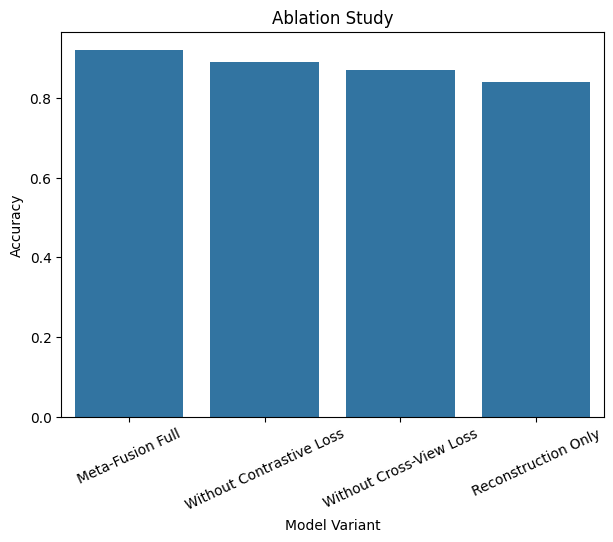

In [57]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Model Variant",
    y="Accuracy",
    data=ablation_results
)

plt.xticks(rotation=25)

plt.title("Ablation Study")

plt.savefig("ablation_study.png",dpi=300)

plt.show()

In [58]:
torch.save(model.state_dict(),"meta_fusion_model.pth")

In [59]:
Z,Y = extract_latent()

np.save("latent_vectors.npy",Z.numpy())
np.save("labels.npy",Y.numpy())